# Lab Experiment 1: Multimodal Data Ingestion in Healthcare
**Objective:** Implementation of program to read tabular, textual, image, signal, and medical data in different formats.

## 1. Environment Setup
Install the necessary packages for tabular, signal, text, and image processing.

In [1]:
!pip install pandas scikit-learn wfdb matplotlib seaborn numpy nltk pillow pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 4.6 MB/s  0:00:006.1 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 5.3 MB/s  0:00:03m 5.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 2.6 MB/s  0:00:005.0 MB/s eta 0:00:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.11.4
    Uninstalling scipy-1.11.4:
      Successfully uninstalled scipy-1.11.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [wfdb]━━━━━━ 1/4 [pydicom]


## 2. Tabular Data Ingestion (UCI Cleveland Heart Disease)
Download dataset, inspect schema, handle missing values, map target, perform EDA, and train a baseline classifier.

Dataset Shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0



Missing values:
 age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


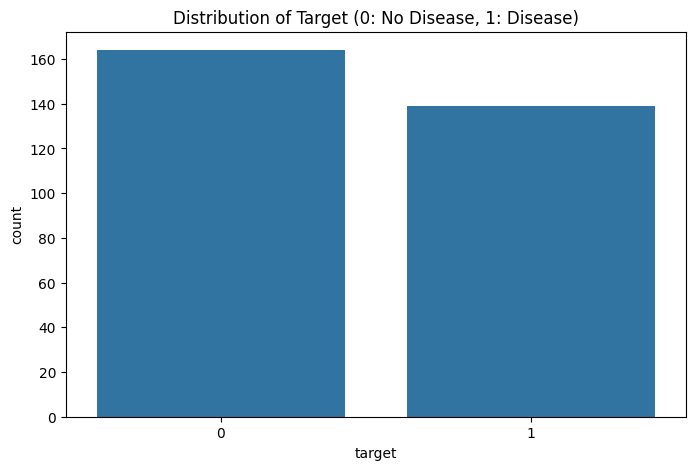

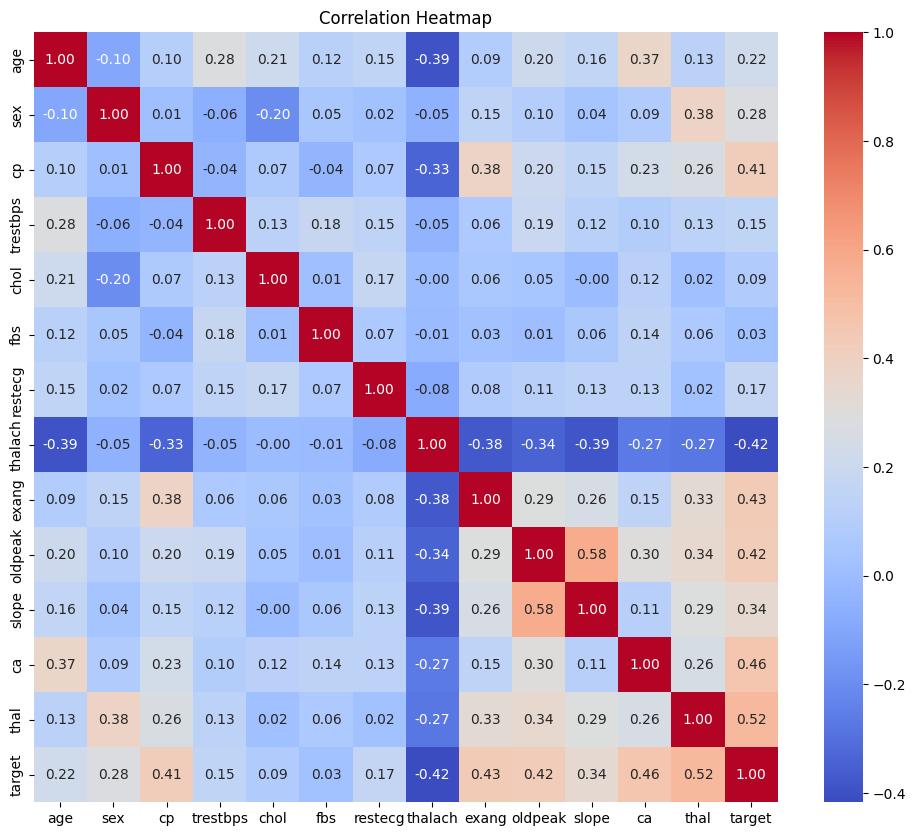


--- Model Evaluation ---
Accuracy: 0.8852459016393442
ROC AUC: 0.9213362068965517

Confusion Matrix:
 [[25  4]
 [ 3 29]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Download the Cleveland Heart Disease dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
column_names = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=column_names, na_values="?")

# 1. Inspect schema
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

# 2. Handle missing values
print("\nMissing values:\n", df.isnull().sum())
# Impute missing values with median for simplicity
imputer = SimpleImputer(strategy='median')
df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)

# 3. Map target to binary (0 vs 1+)
# Target field: 0 = no presence, 1-4 = presence of heart disease
df_imputed['target'] = df_imputed['target'].apply(lambda x: 1 if x > 0 else 0)

# 4. Basic exploratory data analysis
plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=df_imputed)
plt.title('Distribution of Target (0: No Disease, 1: Disease)')
plt.show()

plt.figure(figsize=(12, 10))
sns.heatmap(df_imputed.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

# 5. Train a baseline classifier (Logistic Regression)
X = df_imputed.drop('target', axis=1)
y = df_imputed['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 6. Evaluate
print("\n--- Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

## 3. Signal Data Ingestion (ECG)
Fetch a sample MIT-BIH record using `wfdb`, plot waveform with beat annotations, and compute basic heart-rate statistics.

Fetching record 100 from PhysioNet...
Signal shape: (650000, 2)
Fields: {'fs': 360, 'sig_len': 650000, 'n_sig': 2, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV'], 'sig_name': ['MLII', 'V5'], 'comments': ['69 M 1085 1629 x1', 'Aldomet, Inderal']}


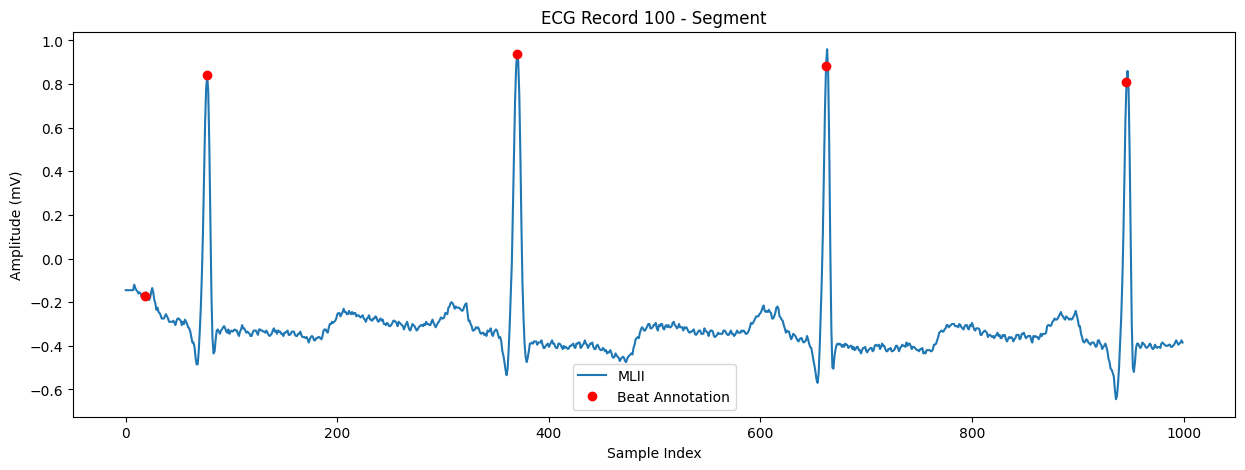


--- Beat Interval Statistics ---
Mean RR Interval: 0.7943 seconds
Std RR Interval: 0.0506 seconds
Approximate Average Heart Rate: 75.54 BPM


In [3]:
import wfdb

# 1. Fetch a sample MIT-BIH record (record '100')
record_name = '100'
print(f"Fetching record {record_name} from PhysioNet...")
record = wfdb.rdrecord(record_name, pn_dir='mitdb')
annotation = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

# 2. Load the signal and annotation
signals, fields = wfdb.rdsamp(record_name, pn_dir='mitdb')
print("Signal shape:", signals.shape)
print("Fields:", fields)

# 3. Plot a segment of ECG waveform with beat annotations
plt.figure(figsize=(15, 5))
plot_samples = 1000
plt.plot(signals[:plot_samples, 0], label=fields['sig_name'][0])

# Overlay annotations within the plot range
ann_idx = annotation.sample < plot_samples
plt.plot(annotation.sample[ann_idx], signals[annotation.sample[ann_idx], 0], 'ro', label='Beat Annotation')

plt.title(f"ECG Record {record_name} - Segment")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude (mV)")
plt.legend()
plt.show()

# 4. Compute basic heart-rate variability or beat interval statistics
rr_intervals = np.diff(annotation.sample)
fs = fields['fs']
rr_intervals_sec = rr_intervals / fs

print("\n--- Beat Interval Statistics ---")
print(f"Mean RR Interval: {np.mean(rr_intervals_sec):.4f} seconds")
print(f"Std RR Interval: {np.std(rr_intervals_sec):.4f} seconds")
print(f"Approximate Average Heart Rate: {60 / np.mean(rr_intervals_sec):.2f} BPM")

## 4. Textual Data Demonstration
Use basic NLP to tokenize, clean, and extract key terms from a synthetic clinical note.

In [4]:
import nltk
from collections import Counter
import re

# Download necessary NLTK data (quietly)
nltk.download('punkt_tab', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

# 1. Synthetic clinical note
clinical_note = """
Patient is a 55-year-old male presenting with severe chest pain, shortness of breath, and diaphoresis. 
The pain radiates to the left arm and jaw. Patient has a history of hypertension and hyperlipidemia.
Current medications include lisinopril and atorvastatin. 
ECG shows ST-segment elevation in leads V2-V4.
Impression: Acute anterior myocardial infarction.
"""

print("Original Clinical Note:\n", clinical_note)

# 2. Tokenize and clean
cleaned_text = re.sub(r'[^\w\s]', '', clinical_note.lower())
tokens = nltk.word_tokenize(cleaned_text)

stopwords_set = set(nltk.corpus.stopwords.words('english'))
filtered_tokens = [word for word in tokens if word not in stopwords_set]

# 3. Compute word frequency and extract key terms
word_freq = Counter(filtered_tokens)

print("\n--- Textual Analysis ---")
print("Top 10 Most Frequent Words (excluding stopwords):")
for word, freq in word_freq.most_common(10):
    print(f"{word}: {freq}")

Original Clinical Note:
 
Patient is a 55-year-old male presenting with severe chest pain, shortness of breath, and diaphoresis. 
The pain radiates to the left arm and jaw. Patient has a history of hypertension and hyperlipidemia.
Current medications include lisinopril and atorvastatin. 
ECG shows ST-segment elevation in leads V2-V4.
Impression: Acute anterior myocardial infarction.


--- Textual Analysis ---
Top 10 Most Frequent Words (excluding stopwords):
patient: 2
pain: 2
55yearold: 1
male: 1
presenting: 1
severe: 1
chest: 1
shortness: 1
breath: 1
diaphoresis: 1


## 5. Image Data Demonstration
Load, display, resize, and extract basic metadata from a synthetic medical image (placeholder for X-ray).

Image Format: PIL Image (Synthetic Grayscale)
Original Size: (256, 256)


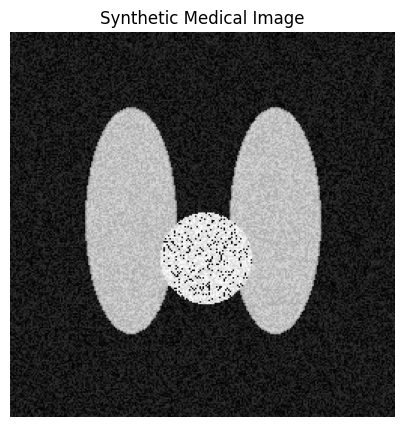

Resized Size: (128, 128)


In [5]:
from PIL import Image, ImageDraw
import numpy as np

# 1. Create a synthetic image (placeholder for a chest X-ray)
width, height = 256, 256
synthetic_xray = Image.new("L", (width, height), "black")
draw = ImageDraw.Draw(synthetic_xray)

# Draw synthetic "lungs" and "heart"
draw.ellipse((50, 50, 110, 200), fill="darkgray", outline="gray")
draw.ellipse((146, 50, 206, 200), fill="darkgray", outline="gray")
draw.ellipse((100, 120, 160, 180), fill="lightgray")

# Add random noise to simulate medical scan texture
noise = np.random.randint(0, 50, (height, width), dtype='uint8')
img_array = np.array(synthetic_xray)
noisy_img_array = np.clip(img_array + noise, 0, 255).astype('uint8')
final_image = Image.fromarray(noisy_img_array)

print("Image Format: PIL Image (Synthetic Grayscale)")
print("Original Size:", final_image.size)

# 2. Display the image
plt.figure(figsize=(5, 5))
plt.imshow(final_image, cmap='gray')
plt.title("Synthetic Medical Image")
plt.axis('off')
plt.show()

# 3. Resize the image (e.g., preprocessing for a CNN)
resized_image = final_image.resize((128, 128))
print("Resized Size:", resized_image.size)